# BioSED: Notebook 2 - Análisis Exploratorio de Datos (EDA) y Representación Acústica de Mel

## 1. Introducción y Objetivos de la Fase EDA

En esta fase del proyecto realizaremos el **Análisis Exploratorio de Datos (EDA)** del corpus acústico [5]. Desde el enfoque del aprendizaje estadístico, un modelo predictivo es tan robusto como la calidad, representatividad e integridad de los datos de entrenamiento sobre los que se optimiza. El objetivo primordial de este notebook es auditar estadísticamente el dataset de volumen masivo que consolidamos en la Fase 1 y justificar físicamente la transformación de nuestras señales acústicas 1D en matrices tiempo-frecuencia (espectrogramas Log-Mel) [5].

Los objetivos específicos de este notebook son:
1.  **Auditoría de Metadatos de Audio**: Analizar distribuciones de volumen de archivos, duraciones reales, tasas de muestreo y balance de clases a nivel de clip para identificar sesgos sistemáticos [5].
2.  **Análisis de Densidad de Cantos**: Caracterizar las etiquetas fuertes generadas por BirdNET (duración de los eventos, distribución de confianza y tasa de cantos activos) para entender la señal de supervisión que recibirá la red neuronal [5].
3.  **Fundamentación Física y Psicoacústica**: Desarrollar formalmente el marco matemático que sustenta la Transformada de Fourier de Tiempo Corto (STFT), la conversión a la escala de Mel y el paso a la escala logarítmica de potencia.
4.  **Visualización e Inspección Espectral**: Graficar comparativamente la onda cruda, la STFT y el Log-Mel de ejemplos reales para cada una de las 10 especies objetivo de Medellín, analizando cualitativamente la complejidad espectral y los posibles traslapes.

## 2. Configuración General del Entorno y Carga de Datos

Para que este análisis exploratorio sea reproducible, inicializaremos las dependencias necesarias de cómputo numérico (`numpy`), análisis tabular (`pandas`), procesamiento de señales acústicas (`librosa`, `torchaudio`) y visualización estadística (`matplotlib`, `seaborn`).

Definiremos las rutas relativas subiendo un nivel de directorio hacia la raíz (`../dataset_aves`) y cargaremos los archivos estructurados que indexamos y saneamos al final de la Fase 1 [5]:
1.  `df_metadata_audios.csv`: Inventario físico validado de nuestros audios MP3 [5].
2.  `df_etiquetas_fuertes.csv`: Registro de segmentos de vocalizaciones con su respectivo mapeo de etiquetas corregido (`especie_target`) [5].

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import torchaudio
import IPython.display as ipd

# Desactivar advertencias de deprecación estéticas de las librerías de audio y visualización
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Configuración estética global para visualizaciones científicas adaptadas para informes
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# Definición de rutas relativas (subiendo un nivel desde la carpeta notebooks/)
BASE_DIR = "../dataset_aves"
METADATA_PATH = os.path.join(BASE_DIR, "df_metadata_audios.csv")
LABELS_PATH = os.path.join(BASE_DIR, "df_etiquetas_fuertes.csv")

# Cargar las tablas unificadas generadas en la Fase 1
if os.path.exists(METADATA_PATH) and os.path.exists(LABELS_PATH):
    df_metadata = pd.read_csv(METADATA_PATH)
    df_labels = pd.read_csv(LABELS_PATH)
    print("Índices de control cargados con éxito:")
    print(f"  - Inventario de audios (df_metadata): {df_metadata.shape[0]} registros, {df_metadata.shape[1]} variables.")
    print(f"  - Etiquetas fuertes (df_labels):     {df_labels.shape[0]} segmentos, {df_labels.shape[1]} variables.")
else:
    print("[ERROR] Archivos df_metadata_audios.csv o df_etiquetas_fuertes.csv no localizados.")
    print("Asegúrate de haber guardado físicamente los archivos al final de la ejecución del Notebook 01.")

Índices de control cargados con éxito:
  - Inventario de audios (df_metadata): 751 registros, 20 variables.
  - Etiquetas fuertes (df_labels):     5641 segmentos, 8 variables.


## 3. Fundamentación Física y Matemática de la Señal Acústica

### 3.1. Representación Física de la Onda y la Señal de Audio Discreta

Físicamente, una onda sonora es una perturbación mecánica de presión $P(t, \mathbf{r})$ que se propaga tridimensionalmente a través de un medio elástico. Al capturar esta perturbación mediante un micrófono (transductor electroacústico), las variaciones de presión de aire se convierten en señales continuas de voltaje en función del tiempo:
$$x(t) \in \mathbb{R}$$

Para almacenar, procesar y entrenar modelos de aprendizaje estadístico sobre estas ondas, es imperativo realizar un proceso de **conversión analógico-digital (ADC)** estructurado en dos etapas discretas: el muestreo temporal y la cuantificación de amplitud.

#### 3.1.1. Muestreo Temporal (Sampling)
Consiste en discretizar el eje temporal continuo tomando lecturas de amplitud a intervalos constantes de tiempo $T_s$, denominado período de muestreo. La frecuencia (o tasa) de muestreo se define como:
$$f_s = \frac{1}{T_s} \quad [\text{Hz}]$$

La señal discreta resultante es una secuencia matemática unidimensional indexada por el entero discreto $n$:
$$x[n] = x(n T_s), \quad \text{con } n = 0, 1, 2, \dots, N-1$$

donde $N$ representa el número total de muestras temporales digitalizadas del clip.

#### 3.1.2. El Teorema de Muestreo de Nyquist-Shannon
Para evitar el fenómeno físico de distorsión por solapamiento espectral (*aliasing*), el teorema de Nyquist-Shannon establece que la frecuencia de muestreo $f_s$ de un sistema de digitalización debe ser estrictamente mayor al doble de la componente espectral de frecuencia máxima $f_{\max}$ contenida en la señal analógica original:
$$f_s > 2 f_{\max}$$

En este proyecto, unificamos la frecuencia de muestreo a $f_s = 32000 \text{ Hz}$ ($32 \text{ kHz}$). Esto implica que el límite de Nyquist de nuestro sistema digital es:
$$f_{\text{Nyquist}} = \frac{f_s}{2} = 16000 \text{ Hz} \quad (16 \text{ kHz})$$

Este límite es óptimo para la bioacústica de aves silvestres, dado que las frecuencias dominantes de vocalización de las 10 especies objetivo seleccionadas del Valle de Aburrá fluctúan principalmente en el espectro de los $1 \text{ kHz}$ a los $12 \text{ kHz}$.

#### 3.1.3. Cuantificación y Normalización de Amplitud (Bit Depth)
Cada muestra discreta obtenida $x[n]$ se cuantifica a un nivel binario finito de amplitud empleando una profundidad de $B$ bits (Bit Depth). Para un formato estándar de codificación PCM de 16 bits ($B=16$), el rango de amplitudes discretas posibles se acota a:
$$x[n] \in [-2^{B-1}, 2^{B-1} - 1] = [-32768, 32767]$$

Para evitar la inestabilidad numérica del gradiente durante la optimización de los pesos de la red neuronal en fases posteriores, normalizaremos estas amplitudes a valores reales continuos en el intervalo simétrico:
$$\hat{x}[n] \in [-1.0, 1.0]$$

### 3.2. Ventanamiento Temporal y la Transformada de Fourier de Tiempo Corto (STFT)

Una señal discreta de audio de campo $x[n]$ es inherentemente **no estacionaria** en el tiempo. Esto significa que sus propiedades estadísticas y sus componentes de frecuencia varían dinámicamente con el tiempo (por ejemplo, las aves alternan silencios, modulan el tono, emiten trinos rápidos o varían armónicos).

Si aplicáramos una Transformada de Fourier Discreta (DFT) convencional sobre el clip completo de audio de longitud $N$:
$$X[k] = \sum_{n=0}^{N-1} x[n] e^{-i \frac{2\pi k n}{N}}$$

obtendríamos un espectro de frecuencias global que nos informaría *qué* componentes armónicas están presentes en el audio, pero perderíamos por completo toda la información de *cuándo* ocurren temporalmente esas componentes, haciendo inviable el problema de SED (Detección de Eventos Sonoros).

#### 3.2.1. Ventanamiento Temporal (Windowing)
Para resolver esta limitación física, aplicamos la hipótesis de **cuasi-estacionariedad**: si tomamos un segmento de señal lo suficientemente corto (típicamente entre $10 \text{ ms}$ y $50 \text{ ms}$), podemos asumir que las propiedades estadísticas y frecuenciales del audio se mantienen estacionarias dentro de esa pequeña vecindad.

Dividimos la señal $x[n]$ en tramas localizadas mediante la multiplicación por una función de ventana $w[n]$ de longitud finita $N_{\text{fft}}$ (como la ventana de Hann o Hamming). El ventanamiento atenúa suavemente a cero las muestras en los bordes de la trama, eliminando las discontinuidades abruptas en las fronteras y mitigando el fenómeno físico de filtración espectral (*spectral leakage*).

#### 3.2.2. Definición Matemática de la STFT
La **Transformada de Fourier de Tiempo Corto (STFT)** calcula la DFT de tramas de audio consecutivas que se desplazan a lo largo del eje del tiempo con un desplazamiento regular medido en muestras, denominado **Hop Length ($H$)**.

Matemáticamente, para el frame de tiempo $m$ y el bin o contenedor de frecuencia $k$, la STFT se define formalmente como [5]:
$$X(m, k) = \sum_{n=0}^{N_{\text{fft}}-1} x[n] w[n - mH] e^{-i \frac{2\pi k n}{N_{\text{fft}}}}$$

Donde:
*   $m$: Índice del frame temporal (representa la dimensión del tiempo en la matriz de salida).
*   $k$: Índice del contenedor o bin de frecuencia (representa la dimensión frecuencial), con $k \in [0, N_{\text{fft}}/2]$ debido a la simetría par de la señal real de entrada.
*   $x[n]$: Señal de audio discreta de entrada.
*   $w[n]$: Función de ventana (en este proyecto usamos la ventana de Hann de longitud $N_{\text{fft}}$).
*   $H$: *Hop Length* o salto temporal entre ventanas sucesivas. En nuestro proyecto está definido en $H = 512$ muestras.
*   $N_{\text{fft}}$: Tamaño de la FFT y longitud de la ventana (en muestras). En nuestro proyecto está definido en $N_{\text{fft}} = 1024$ muestras.

#### 3.2.3. Resolución Espacio-Temporal y el Principio de Incertidumbre de Gabor
Al igual que en mecánica cuántica existe una relación de incertidumbre de posición-momento de Heisenberg, en la física de ondas y análisis de señales rige el **principio de incertidumbre de Gabor**. No es físicamente posible conocer de forma simultánea y con precisión infinita el instante temporal exacto de un evento y su componente de frecuencia pura:
*   Una ventana estrecha (pequeño $N_{\text{fft}}$) mejora la resolución temporal (localiza muy bien el inicio de un canto) pero disminuye la resolución frecuencial (los contenedores espectrales se ensanchan).
*   Una ventana ancha (grande $N_{\text{fft}}$) mejora la resolución frecuencial (separa muy bien armónicos cercanos de trinos) pero degrada la resolución temporal (difumina los bordes del canto).

Nuestra parametrización de $N_{\text{fft}} = 1024$ muestras (que a $32 \text{ kHz}$ equivale a una ventana física de $\approx 32 \text{ ms}$) y un desplazamiento de $H = 512$ muestras ($\approx 16 \text{ ms}$) ofrece un balance espacio-temporal físicamente balanceado para discriminar de forma óptima los patrones rápidos de los cantos de aves.

### 3.3. El Espectrograma de Potencia

El resultado de aplicar la Transformada de Fourier de Tiempo Corto (STFT) sobre la señal digital de audio es una matriz de números complejos:
$$X(m, k) \in \mathbb{C}$$

Cada elemento de la matriz $X(m, k)$ contiene tanto la amplitud como la fase de la componente de frecuencia $k$ en la trama de tiempo $m$. En forma polar, esto se representa como:
$$X(m, k) = |X(m, k)| e^{i \phi(m, k)}$$

donde $|X(m, k)|$ es la magnitud y $\phi(m, k)$ es el ángulo de fase de la oscilación analizada.

#### 3.3.1. Justificación Física para la Eliminación de la Fase
En tareas de reconocimiento bioacústico y clasificación de eventos sonoros, la información de fase $\phi(m, k)$ se descarta intencionalmente. Físicamente, la fase es sumamente inestable y sensible: ligeras variaciones en la distancia física entre el ave y el micrófono, el rebote del sonido en el follaje o en los troncos de los árboles (ecos multipath) y sutiles cambios en las corrientes de aire alteran drásticamente la fase. Sin embargo, estas variaciones ambientales no modifican la taxonomía ni la firma del canto de la especie. 

Por el contrario, la magnitud del espectro contiene la distribución de energía característica de los silbidos y trinos, la cual resulta invariante frente a las condiciones del canal de propagación acústico.

#### 3.3.2. Definición Matemática de la Densidad Espectral de Potencia
El **Espectrograma de Potencia** $S(m, k)$ se obtiene calculando el cuadrado de la magnitud de la STFT compleja, representando físicamente la densidad espectral de energía localizada temporalmente:
$$S(m, k) = |X(m, k)|^2$$

Matemáticamente, si expresamos $X(m, k)$ en términos de sus componentes reales e imaginarias obtenidas tras la DFT:
$$X(m, k) = \text{Re}\{X(m, k)\} + i \text{Im}\{X(m, k)\}$$

El espectrograma de potencia se calcula directamente en el plano real como:
$$S(m, k) = \left(\text{Re}\{X(m, k)\}\right)^2 + \left(\text{Im}\{X(m, k)\}\right)^2$$

La matriz resultante $S(m, k) \in \mathbb{R}^+$ es bidimensional, de valores reales no negativos, y representa el mapa de energía de la señal acústica en la rejilla tiempo-frecuencia. Esta matriz es la base que transformaremos posteriormente para adecuarla a la percepción biológica.

### 3.4. La Escala Psicoacústica de Mel

Aunque la física clásica mide la frecuencia de una onda en Hertz ($\text{Hz}$) de forma estrictamente lineal (número de ciclos de presión por segundo), los sistemas de recepción biológicos (incluyendo los aparatos auditivos de los seres humanos y de las aves) no perciben la altura tonal (*pitch*) de manera lineal.

#### 3.4.1. El Mecanismo Perceptual Biológico y la Cóclea
El procesamiento de ondas en el oído interno se rige por un mapa tonotópico a lo largo de la cóclea (o de la papila basilar en las aves). El diseño biomecánico de estas membranas provoca que los sensores dedicados a las bajas frecuencias estén distribuidos espacialmente con mucha mayor densidad que los de las altas frecuencias. Por ejemplo:
*   Un cambio físico de $100 \text{ Hz}$ a $200 \text{ Hz}$ se percibe como una distancia tonal inmensa (una octava física completa).
*   Un cambio físico de $10000 \text{ Hz}$ a $10100 \text{ Hz}$ (el mismo incremento neto de $100 \text{ Hz}$) resulta casi imperceptible para el analizador biológico.

#### 3.4.2. Definición Matemática de la Escala Mel
La **escala de Mel** es una escala psicoacústica de tonos diseñada de forma que distancias iguales en Mel correspondan a distancias que los sujetos perciben como auditivamente iguales. El punto de calibración estándar de la escala define que un tono puro de $1000 \text{ Hz}$ a un nivel de volumen de $40 \text{ dB}$ sobre el umbral de audición equivale exactamente a $1000 \text{ mels}$.

La conversión matemática que mapea una frecuencia física $f$ expresada en Hertz a una frecuencia perceptual $m$ en Mels se modela mediante la función:
$$m = 2595 \log_{10}\left(1 + \frac{f}{700}\right)$$

O en su formulación matemática equivalente utilizando logaritmo natural:
$$m = 1127 \ln\left(1 + \frac{f}{700}\right)$$

*(Nota: Físicamente las expresiones coinciden dado que $2595 / \ln(10) \approx 1127.5$)*.

#### 3.4.3. Límites Asintóticos de la Escala
Al analizar matemáticamente el comportamiento de la función ante diferentes regímenes de frecuencia, se evidencian dos comportamientos bien definidos:
1.  **Comportamiento Cuasi-Lineal ($f \ll 700 \text{ Hz}$)**: Al aplicar una aproximación de Taylor de primer orden $\ln(1+y) \approx y$ para valores pequeños, la relación se aproxima a una recta:
    $$m \approx 1127 \left(\frac{f}{700}\right) \approx 1.61 f$$
2.  **Comportamiento Logarítmico ($f \gg 700 \text{ Hz}$)**: Cuando la frecuencia física supera ampliamente el polo de $700 \text{ Hz}$, la constante $1$ se vuelve matemáticamente despreciable, tornando la respuesta puramente logarítmica:
    $$m \approx 1127 \ln\left(\frac{f}{700}\right)$$

Esta respuesta de compresión espectral es un reflejo de la **Ley de Weber-Fechner**, que establece que la intensidad de la respuesta ante un estímulo físico crece logarítmicamente con la magnitud de dicho estímulo. Al mapear el espectrograma lineal a la escala Mel, logramos que la entrada de nuestro modelo se concentre en los rangos frecuenciales más ricos en firmas biológicas (descartando la redundancia espectral de las altas frecuencias).

### 3.5. Banco de Filtros Mel y la Representación Log-Mel

Para transformar de forma computacional la matriz de espectrograma de potencia lineal $S(m, k)$ en una representación compatible con los principios psicoacústicos, aplicamos una operación matemática de filtrado espacial denominada **Banco de Filtros de Mel**.

#### 3.5.1. Construcción del Banco de Filtros Triangulares
Este banco está constituido por un conjunto de $J$ filtros de respuesta al impulso triangulares ($B_j(k)$, con $j = 1, 2, \dots, J$). Estos filtros se caracterizan por estar espaciados de manera lineal en la escala de Mel, lo que se traduce en un espaciamiento logarítmico con anchos de banda crecientes al ser convertidos de vuelta a Hertz.

Para definir matemáticamente los $J$ filtros, seleccionamos $J+2$ puntos de frecuencia de corte equiespaciados en la escala Mel, los transformamos a Hertz utilizando la función inversa de conversión de Stevens y los mapeamos a sus bines de frecuencia discretos correspondientes de la FFT ($f(j)$). La respuesta en frecuencia de cada filtro triangular $j$ se define analíticamente como:
$$B_j(k) = \begin{cases} 
0 & \text{si } k < f(j-1) \\
\frac{k - f(j-1)}{f(j) - f(j-1)} & \text{si } f(j-1) \le k \le f(j) \\
\frac{f(j+1) - k}{f(j+1) - f(j)} & \text{si } f(j) < k \le f(j+1) \\
0 & \text{si } k > f(j+1)
\end{cases}$$

En este proyecto, configuramos $J = 64$ filtros Mel (`n_mels = 64`). Esto reduce la dimensión espectral vertical de la STFT de $N_{\text{fft}}/2 + 1 = 513$ bines lineales de frecuencia a únicamente $64$ bines psicoacústicos.

#### 3.5.2. Producto Punto Matricial (Multiplicación Espectral)
La conversión de la matriz de potencia a la representación de escala de Mel se calcula operando mediante un producto punto matricial la densidad de energía de la STFT por la matriz del banco de filtros de Mel. Esto colapsa las bandas lineales de Fourier en canales de percepción auditiva:
$$\tilde{S}(m, j) = \sum_{k} S(m, k) B_j(k)$$

#### 3.5.3. Compresión Logarítmica (Log-Mel)
El aparato auditivo biológico de los vertebrados no solo cuantifica de forma no lineal la frecuencia, sino también la amplitud de presión de la señal física (percepción logarítmica de volumen). El rango dinámico entre un silencio sutil en el fondo del bosque y la vocalización potente de un ave cercana puede abarcar varios órdenes de magnitud de energía de potencia física.

Para emular esta respuesta perceptual y normalizar los rangos dinámicos en favor del entrenamiento numérico de la red neuronal, aplicamos una transformación logarítmica sobre la señal espectral colapsada en la escala Mel, obteniendo el **Log-Mel Spectrogram**:
$$M(m, j) = \log\left(\epsilon + \tilde{S}(m, j)\right)$$

Donde:
*   $M(m, j)$: Coeficiente espectral Log-Mel final para el frame temporal $m$ y el filtro de Mel $j$.
*   $\tilde{S}(m, j)$: Energía espectral de potencia concentrada por el filtro Mel $j$ en el frame $m$.
*   $\epsilon$: Constante de protección infinitesimal de punto flotante (típicamente $\epsilon = 10^{-5}$) añadida para evitar la indeterminación matemática del logaritmo de cero ($\log(0)$) durante tramos de silencio absoluto de la grabación.

### 3.6. Conexión entre la Física de Señales y el Aprendizaje Estadístico

Desde la perspectiva del Aprendizaje Estadístico (*Statistical Machine Learning*), la señal discreta cruda de amplitud de onda $x[n]$ planteada en su dominio temporal unidimensional original presenta retos severos para el modelado de redes neuronales:
1.  **Alta dimensionalidad y redundancia temporal**: Un clip de audio estándar de 10 segundos muestreado a nuestra tasa unificada de $32 \text{ kHz}$ contiene un vector unidimensional de $320,000$ muestras de amplitud de presión, lo que exige una enorme cantidad de parámetros e incrementa drásticamente la inestabilidad de convergencia del modelo.
2.  **Baja invarianza a la traslación temporal**: Si un evento acústico (un canto) ocurre ligeramente más temprano o más tarde en la grabación, la fase y la amplitud física instantánea de los puntos $x[n]$ cambia drásticamente en el dominio del tiempo, haciendo que una red neuronal densamente conectada (MLP) sufra de sobreajuste (*overfitting*) al intentar rastrear estas traslaciones directas.

#### 3.6.1. El Espectrograma Log-Mel como una "Imagen" 2D
Al aplicar la transformación de Fourier localizada (STFT), colapsar el espectro en bines no lineales de Mel y calcular la escala logarítmica de decibeles, la serie de tiempo cruda $x[n] \in \mathbb{R}^{320,000}$ se comprime en una representación matricial estructurada:
$$M \in \mathbb{R}^{T \times J}$$

Donde, para las dimensiones físicas configuradas en nuestro sistema:
*   $T \approx 625$ columnas temporales (eje horizontal de frames).
*   $J = 64$ bines de filtros de Mel (eje vertical psicoacústico).

Cada componente $(m, j)$ de la matriz de características $M$ representa la densidad espectral de energía localizada (en decibeles). Desde el punto de vista computacional, esto convierte el problema de procesamiento de audio en un problema de **visión por computadora de un canal** (equivalente a una imagen en escala de grises o mapa térmico).

#### 3.6.2. Justificación Geométrica del uso de Redes Convolucionales 2D (CNN)
La aplicación de Redes Convolucionales (CNN 2D) sobre espectrogramas acústicos es idónea debido a los patrones de firma geométrica que las vocalizaciones de las aves dibujan sobre la rejilla de tiempo-frecuencia:
*   **Silbidos y Armónicos de Tono Puro**: Se manifiestan como líneas puramente horizontales (alta energía concentrada en un bin Mel constante a lo largo de múltiples frames de tiempo).
*   **Chirridos e Impulsos Rápidos de Banda Ancha**: Se manifiestan como líneas puramente verticales (energía acústica distribuida de forma instantánea a lo largo de todo el espectro de Mel en un frame muy estrecho).
*   **Modulaciones de Frecuencia y Trinos**: Se manifiestan como líneas diagonales, curvas u oscilaciones armónicas continuas (variaciones de la frecuencia en función de la evolución del tiempo).

Las capas de convolución de la red neuronal aplican núcleos de filtrado (kernels) locales de tamaño espacial $K_h \times K_w$ que escanean la matriz $M$. Estos kernels detectan de forma robusta e invariante a la traslación características locales de bajo nivel (como pendientes frecuenciales de ataque, bordes de silencio u oscilaciones periódicas). Las operaciones posteriores de reducción espacial (*pooling*) en la dimensión frecuencial agregan tolerancia a ligeras variaciones de frecuencia individuales entre aves de la misma especie (asimilable a la invarianza a cambios de tono).

#### 3.6.3. Estructuración Secuencial para SED mediante Recurrencia (BiGRU)
Finalmente, dado que el objetivo de SED es predecir de forma temporal el instante exacto de inicio y fin del canto, el mapa de características espaciales resultante de la CNN se secuencia cronológicamente y se alimenta a una Red Neuronal Recurrente Bidireccional (BiGRU). La capa recurrente rastrea la evolución a largo plazo de los patrones de energía, permitiendo estimar la probabilidad condicional de ocurrencia del evento por cada frame individual $t$ y especie de ave $c$:
$$P(Y_{t,c} = 1 \mid M)$$

## 4. Análisis Exploratorio Estadístico (EDA) del Dataset

### 4.1. Análisis de Balance de Clases a Nivel de Clip (Archivos de Audio)

Comenzaremos nuestro análisis exploratorio auditando estadísticamente la distribución de las clases a nivel de archivo de audio (clip) [5]. En el entrenamiento de clasificadores supervisados, contar con un corpus balanceado es fundamental para impedir que el modelo desarrolle sesgos sistemáticos (como sobreestimar a favor de clases mayoritarias con mayor volumen de ejemplos de entrenamiento).

Durante la fase de diseño, impusimos un límite de descarga de 120 audios por especie en Colombia [5]. No obstante, debido a restricciones de muestreo biogeográfico en la base de datos de *Xeno-Canto*, varias especies presentan un número total de grabaciones menor a dicho umbral. Analizaremos esta distribución física de entrada a continuación.

=== DISTRIBUCIÓN DE CLASES A NIVEL DE CLIP ===
Total de archivos de audio físicamente válidos: 751


,Especie Objetivo,Cantidad de Clips,Porcentaje (%)
0,Zonotrichia capensis,100,13.32
1,Pitangus sulphuratus,99,13.18
2,Troglodytes aedon,99,13.18
3,Tyrannus melancholicus,86,11.45
4,Crotophaga ani,83,11.05
5,Campylorhynchus griseus,74,9.85
6,Thraupis episcopus,71,9.45
7,Turdus ignobilis,60,7.99
8,Thraupis palmarum,46,6.13
9,Pygochelidon cyanoleuca,33,4.39


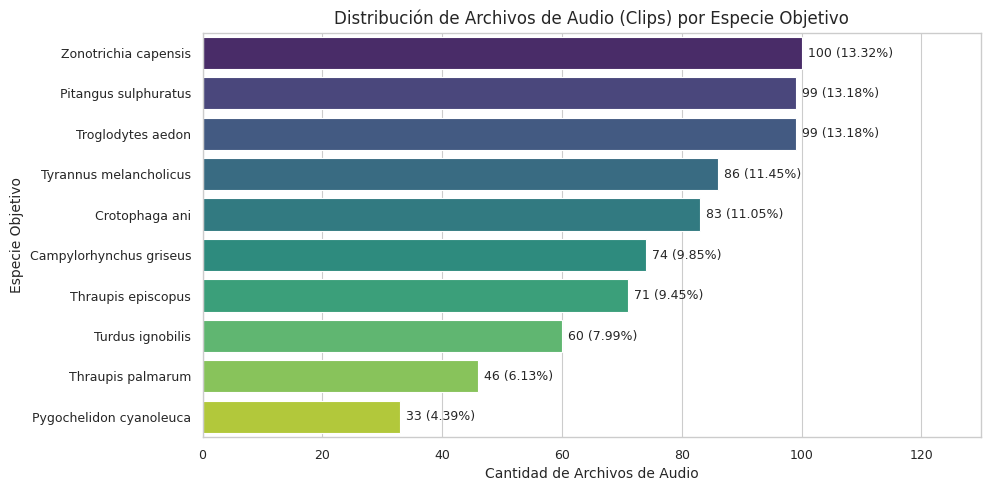

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/balance_clips_especies.png


In [2]:
# Asegurar que el directorio de salida físico para las figuras del EDA exista
os.makedirs("../artifacts/figures/eda", exist_ok=True)

# 1. Calcular frecuencias absolutas y porcentajes de clips por especie
conteo_clips = df_metadata["especie_esperada"].value_counts()
porcentaje_clips = df_metadata["especie_esperada"].value_counts(normalize=True) * 100

# Consolidar estadísticas descriptivas en un DataFrame unificado
df_balance_clips = pd.DataFrame({
    "Cantidad de Clips": conteo_clips,
    "Porcentaje (%)": porcentaje_clips.round(2)
})
df_balance_clips.index.name = "Especie Objetivo"
df_balance_clips.reset_index(inplace=True)

print("=== DISTRIBUCIÓN DE CLASES A NIVEL DE CLIP ===")
print(f"Total de archivos de audio físicamente válidos: {len(df_metadata)}")
display(df_balance_clips)

# 2. Generar gráfico estadístico de barras horizontales usando Seaborn
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_balance_clips,
    x="Cantidad de Clips",
    y="Especie Objetivo",
    palette="viridis",
    hue="Especie Objetivo",
    legend=False
)

# Agregar etiquetas de texto al final de cada barra para facilitar la lectura rápida
for index, row in df_balance_clips.iterrows():
    plt.text(
        row["Cantidad de Clips"] + 1, 
        index, 
        f"{row['Cantidad de Clips']} ({row['Porcentaje (%)']}%)", 
        va="center", 
        fontsize=9
    )

plt.title("Distribución de Archivos de Audio (Clips) por Especie Objetivo")
plt.xlabel("Cantidad de Archivos de Audio")
plt.ylabel("Especie Objetivo")
plt.xlim(0, 130)  # Dejar margen a la derecha para acomodar las etiquetas de texto
plt.tight_layout()

# 3. Guardar físicamente la gráfica en la carpeta de figuras para informes o sustentación
fig_path = "../artifacts/figures/eda/balance_clips_especies.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path)}")

### 4.2. Análisis de Duración Real de las Grabaciones de Audio

La duración de las grabaciones acústicas crudas recolectadas es un factor analítico determinante para el volumen de información y la factibilidad computacional del entrenamiento. Al abordar tareas de detección de eventos sonoros (SED) cuadro a cuadro, la presencia de clips de longitudes muy variables influye drásticamente en cómo la red neuronal convolucional recurrente (CRNN) asimila el contexto temporal.

Analizaremos estadísticamente la distribución de las duraciones reales en segundos de las grabaciones obtenidas de *Xeno-Canto*, las cuales fueron físicamente medidas y saneadas mediante `torchaudio` durante la Fase 1 [5].

=== ESTADÍSTICAS DE DURACIÓN DEL CORPUS ACÚSTICO ===
Total de tiempo acumulado: 31144.01 segundos (8.65 horas)
Duración promedio (media): 41.47 segundos
Duración mediana:          28.53 segundos
Desviación estándar:       105.45 segundos
Duración mínima:           0.95 segundos
Duración máxima:           2739.70 segundos



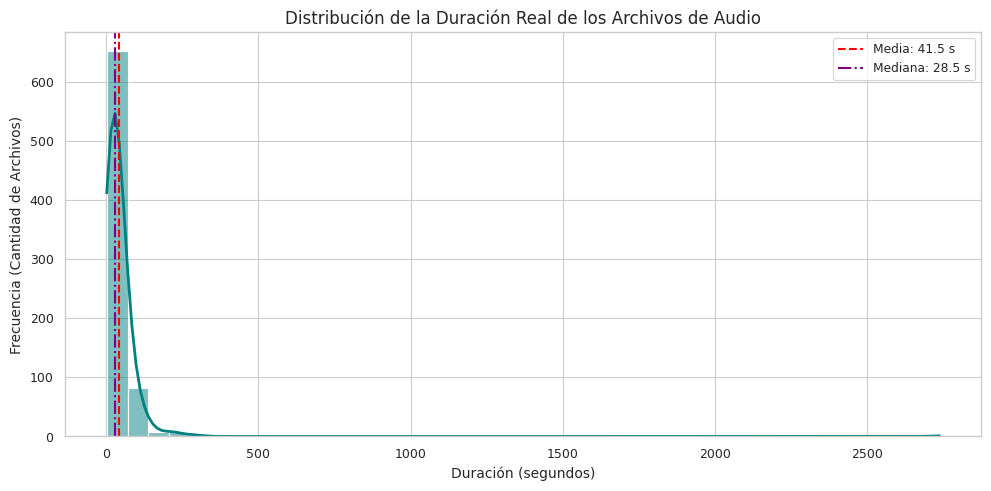

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/distribucion_duracion_audios.png


In [3]:
# 1. Calcular estadísticas descriptivas básicas
duraciones = df_metadata["duracion_real"]
total_segundos = duraciones.sum()
total_horas = total_segundos / 3600

print("=== ESTADÍSTICAS DE DURACIÓN DEL CORPUS ACÚSTICO ===")
print(f"Total de tiempo acumulado: {total_segundos:.2f} segundos ({total_horas:.2f} horas)")
print(f"Duración promedio (media): {duraciones.mean():.2f} segundos")
print(f"Duración mediana:          {duraciones.median():.2f} segundos")
print(f"Desviación estándar:       {duraciones.std():.2f} segundos")
print(f"Duración mínima:           {duraciones.min():.2f} segundos")
print(f"Duración máxima:           {duraciones.max():.2f} segundos\n")

# 2. Graficar distribución con un histograma y estimación de densidad de kernel (KDE)
plt.figure(figsize=(10, 5))
sns.histplot(
    duraciones,
    kde=True,
    color="teal",
    bins=40,
    line_kws={"linewidth": 2}
)

# Agregar líneas indicativas para la media y la mediana
plt.axvline(duraciones.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Media: {duraciones.mean():.1f} s")
plt.axvline(duraciones.median(), color="purple", linestyle="-.", linewidth=1.5, label=f"Mediana: {duraciones.median():.1f} s")

plt.title("Distribución de la Duración Real de los Archivos de Audio")
plt.xlabel("Duración (segundos)")
plt.ylabel("Frecuencia (Cantidad de Archivos)")
plt.legend()
plt.tight_layout()

# 3. Guardar la figura física en el directorio de artefactos del EDA
fig_path_duracion = "../artifacts/figures/eda/distribucion_duracion_audios.png"
plt.savefig(fig_path_duracion, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path_duracion)}")

### 4.3. Análisis de Parámetros Técnicos de los Archivos de Audio (Tasa de Muestreo y Canales)

Los archivos acústicos recolectados de plataformas abiertas como *Xeno-Canto* son registrados de manera asíncrona por decenas de autores empleando equipos de grabación muy diversos (grabadoras portátiles profesionales, teléfonos inteligentes, micrófonos de solapa o parábolas direccionales). Esto da lugar a una alta heterogeneidad en las especificaciones técnicas del audio de entrada original, principalmente en:
1.  **La Tasa de Muestreo (*Sample Rate*)**: Diferentes estándares de digitalización de tarjetas de sonido (comúnmente $44.1\text{ kHz}$ o $48\text{ kHz}$).
2.  **El Número de Canales**: Grabaciones monofónicas (mono, canal único de presión) frente a grabaciones estereofónicas (estéreo, dos canales con desfase espacial).

Para garantizar un modelado unificado y con bases matemáticas estables en nuestra CRNN, durante la fase de procesamiento de audio estandarizaremos estas diferencias (remuestreando obligatoriamente a $32\text{ kHz}$ y promediando a un solo canal mono) [5]. No obstante, es una práctica metodológica indispensable auditar la composición técnica original del corpus físico a través del siguiente análisis de frecuencias.

=== DISTRIBUCIÓN DE TASAS DE MUESTREO REALES ===
  - 44100 Hz: 512 archivos (68.18%)
  - 48000 Hz: 217 archivos (28.89%)
  - 96000 Hz: 6 archivos (0.80%)
  - 16000 Hz: 4 archivos (0.53%)
  - 24000 Hz: 3 archivos (0.40%)
  - 192000 Hz: 3 archivos (0.40%)
  - 22050 Hz: 3 archivos (0.40%)
  - 32000 Hz: 2 archivos (0.27%)
  - 8000 Hz: 1 archivos (0.13%)

=== DISTRIBUCIÓN DE CANALES REALES ===
  - 2 canal(es) (Estéreo): 435 archivos (57.92%)
  - 1 canal(es) (Mono): 316 archivos (42.08%)


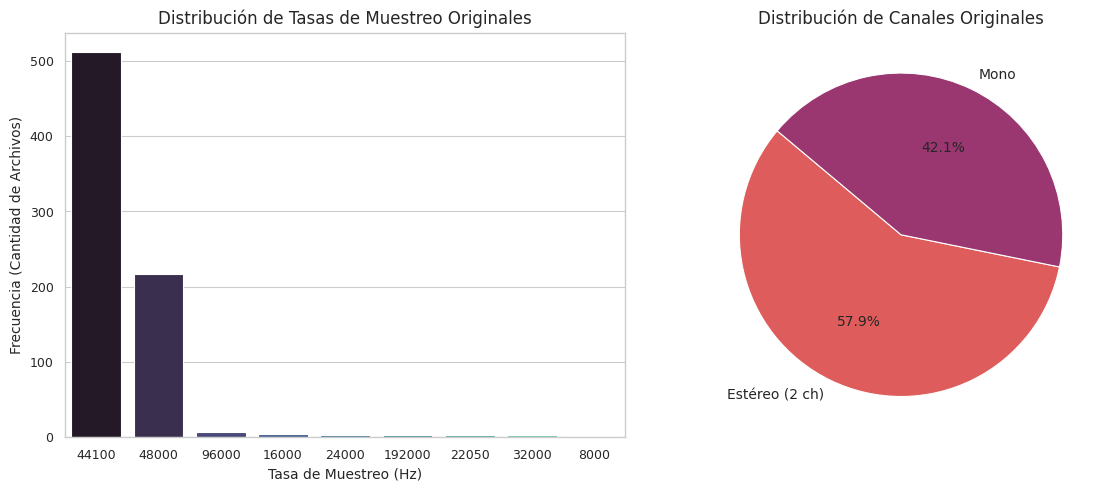

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/parametros_tecnicos_audios.png


In [4]:
# 1. Calcular distribuciones de frecuencia de tasas de muestreo y canales reales medidos en el paso 1.6
dist_sample_rates = df_metadata["sample_rate_real"].value_counts()
dist_canales = df_metadata["canales_real"].value_counts()

print("=== DISTRIBUCIÓN DE TASAS DE MUESTREO REALES ===")
for rate, count in dist_sample_rates.items():
    percentage = (count / len(df_metadata)) * 100
    print(f"  - {int(rate)} Hz: {count} archivos ({percentage:.2f}%)")

print("\n=== DISTRIBUCIÓN DE CANALES REALES ===")
for channels, count in dist_canales.items():
    tipo = "Estéreo" if channels > 1 else "Mono"
    percentage = (count / len(df_metadata)) * 100
    print(f"  - {int(channels)} canal(es) ({tipo}): {count} archivos ({percentage:.2f}%)")

# 2. Generar lienzo de subplots compartidos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Distribución de Tasas de Muestreo
if len(dist_sample_rates) <= 5:
    axes[0].pie(
        dist_sample_rates, 
        labels=[f"{int(r)} Hz" for r in dist_sample_rates.index], 
        autopct='%1.1f%%', 
        colors=sns.color_palette("mako", len(dist_sample_rates)),
        startangle=90,
        textprops={'fontsize': 10}
    )
else:
    sns.barplot(
        x=dist_sample_rates.index.astype(int).astype(str), 
        y=dist_sample_rates.values, 
        ax=axes[0], 
        palette="mako"
    )
    axes[0].set_xlabel("Tasa de Muestreo (Hz)")
    axes[0].set_ylabel("Frecuencia (Cantidad de Archivos)")

axes[0].set_title("Distribución de Tasas de Muestreo Originales")

# Subplot 2: Distribución de Canales (Mono vs Estéreo)
canales_labels = ["Mono" if c == 1 else f"Estéreo ({int(c)} ch)" for c in dist_canales.index]
axes[1].pie(
    dist_canales,
    labels=canales_labels,
    autopct='%1.1f%%',
    colors=sns.color_palette("flare", len(dist_canales)),
    startangle=140,
    textprops={'fontsize': 10}
)
axes[1].set_title("Distribución de Canales Originales")

plt.tight_layout()

# 3. Guardar físicamente la figura en disco para informes o presentación
fig_path_tech = "../artifacts/figures/eda/parametros_tecnicos_audios.png"
plt.savefig(fig_path_tech, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path_tech)}")

### 4.4. Análisis de Cantidad de Eventos de Canto por Especie Objetivo

En el análisis de balance a nivel de clip observamos que la distribución física de archivos está supeditada únicamente a la disponibilidad en Xeno-Canto [5]. No obstante, en un modelo de Detección de Eventos Sonoros (SED) frame-a-frame, la verdadera señal de supervisión y balance se mide a través de la **cantidad de segmentos de canto individuales (eventos)** y su respectivo tiempo activo.

Aunque controlemos de manera rígida el número de audios por carpeta, la cantidad de cantos detectados variará de forma natural debido a los hábitos de vocalización y comunicación de cada especie (algunas especies emiten trinos muy continuos de carácter gregario o territorial frente a otras con llamados esporádicos y espaciados). Analizaremos esta distribución a continuación a partir de los datos consolidados en la tabla de etiquetas fuertes `df_labels` [5].

=== DISTRIBUCIÓN DE CANTIDAD DE EVENTOS DE CANTO ===
Total de segmentos de cantos activos (etiquetas fuertes): 5641


,Especie,Cantidad de Eventos,Porcentaje (%)
0,Zonotrichia capensis,771,13.67
1,Turdus ignobilis,742,13.15
2,Pitangus sulphuratus,707,12.53
3,Thraupis episcopus,682,12.09
4,Crotophaga ani,593,10.51
5,Campylorhynchus griseus,573,10.16
6,Tyrannus melancholicus,492,8.72
7,Thraupis palmarum,475,8.42
8,Troglodytes aedon,371,6.58
9,Pygochelidon cyanoleuca,235,4.17


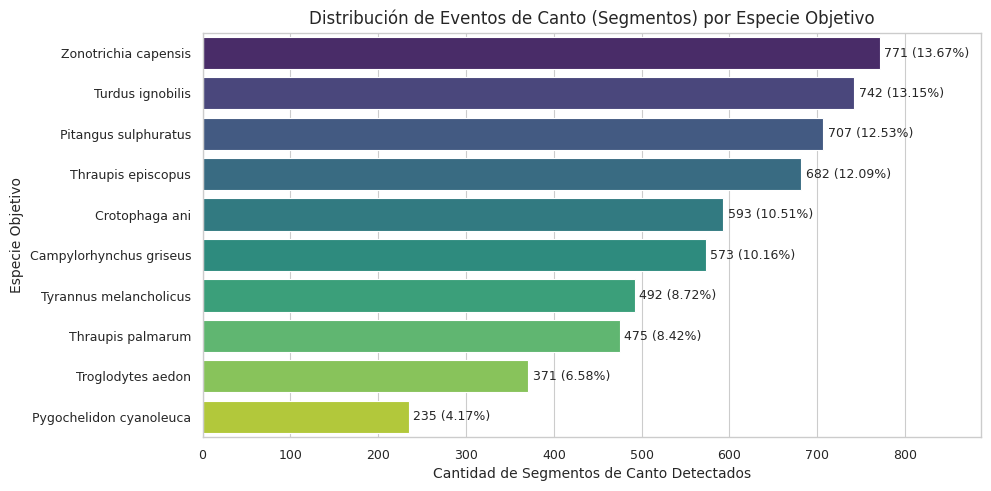

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/cantidad_eventos_especie.png


In [5]:
# 1. Calcular frecuencias absolutas y porcentajes de eventos por especie target
conteo_eventos = df_labels["especie_target"].value_counts()
porcentaje_eventos = df_labels["especie_target"].value_counts(normalize=True) * 100

# Consolidar estadísticas descriptivas en un DataFrame unificado
df_balance_eventos = pd.DataFrame({
    "Cantidad de Eventos": conteo_eventos,
    "Porcentaje (%)": porcentaje_eventos.round(2)
})
df_balance_eventos.index.name = "Especie"
df_balance_eventos.reset_index(inplace=True)

print("=== DISTRIBUCIÓN DE CANTIDAD DE EVENTOS DE CANTO ===")
print(f"Total de segmentos de cantos activos (etiquetas fuertes): {len(df_labels)}")
display(df_balance_eventos)

# 2. Generar gráfico estadístico de barras horizontales usando Seaborn
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_balance_eventos,
    x="Cantidad de Eventos",
    y="Especie",
    palette="viridis",
    hue="Especie",
    legend=False
)

# Agregar etiquetas de valores al final de cada barra para facilitar la lectura rápida
for index, row in df_balance_eventos.iterrows():
    plt.text(
        row["Cantidad de Eventos"] + 5, 
        index, 
        f"{row['Cantidad de Eventos']} ({row['Porcentaje (%)']}%)", 
        va="center", 
        fontsize=9
    )

plt.title("Distribución de Eventos de Canto (Segmentos) por Especie Objetivo")
plt.xlabel("Cantidad de Segmentos de Canto Detectados")
plt.ylabel("Especie Objetivo")

# Ajustar el margen horizontal dinámicamente según el conteo máximo para que quepan las etiquetas
plt.xlim(0, df_balance_eventos["Cantidad de Eventos"].max() * 1.15)
plt.tight_layout()

# 3. Guardar físicamente la figura en disco para informes o presentación
fig_path_eventos = "../artifacts/figures/eda/cantidad_eventos_especie.png"
plt.savefig(fig_path_eventos, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path_eventos)}")

### 4.5. Análisis de Duración de los Eventos de Canto por Especie

Además de la frecuencia de aparición, la **duración individual** de cada evento de canto es un parámetro físico sumamente informativo. Algunas especies emiten cantos largos, melódicos y estructurados (canciones complejas), mientras que otras emiten llamados cortos, secos, percutidos o ráfagas continuas de clics.

Desde la perspectiva del aprendizaje profundo en series de tiempo con la CRNN, la duración de estos eventos define la escala y la contigüidad de las etiquetas activas (las secuencias consecutivas de "unos" en el *target_matrix*):
*   **Eventos muy cortos**: Plantean un reto espacial para la CNN. Al aplicar operaciones de reducción de resolución (*Max-Pooling*) a lo largo de las tramas de tiempo, eventos sumamente breves corren el riesgo de ser difuminados o colapsados antes de alcanzar las capas de predicción.
*   **Eventos largos**: Exigen que la capa recurrente (BiGRU) mantenga memoria contextual a largo plazo y capture de forma consistente los límites del evento (*onset* y *offset*).

Analizaremos estadísticamente la distribución temporal de estos segmentos calculando la duración real de cada evento de canto registrado ($t_{\text{fin}} - t_{\text{inicio}}$) y comparándolos por especie mediante gráficos de caja (*boxplots*) [5].

=== ESTADÍSTICAS DE DURACIÓN DE EVENTOS DE CANTO POR ESPECIE ===


,Cantidad_Eventos,Media_s,Mediana_s,Desviacion_s,Minimo_s,Maximo_s
especie_target,,,,,,
Campylorhynchus griseus,573,3.0,3.0,0.0,3.0,3.0
Crotophaga ani,593,3.0,3.0,0.0,3.0,3.0
Pitangus sulphuratus,707,3.0,3.0,0.0,3.0,3.0
Pygochelidon cyanoleuca,235,3.0,3.0,0.0,3.0,3.0
Thraupis episcopus,682,3.0,3.0,0.0,3.0,3.0
Thraupis palmarum,475,3.0,3.0,0.0,3.0,3.0
Troglodytes aedon,371,3.0,3.0,0.0,3.0,3.0
Turdus ignobilis,742,3.0,3.0,0.0,3.0,3.0
Tyrannus melancholicus,492,3.0,3.0,0.0,3.0,3.0


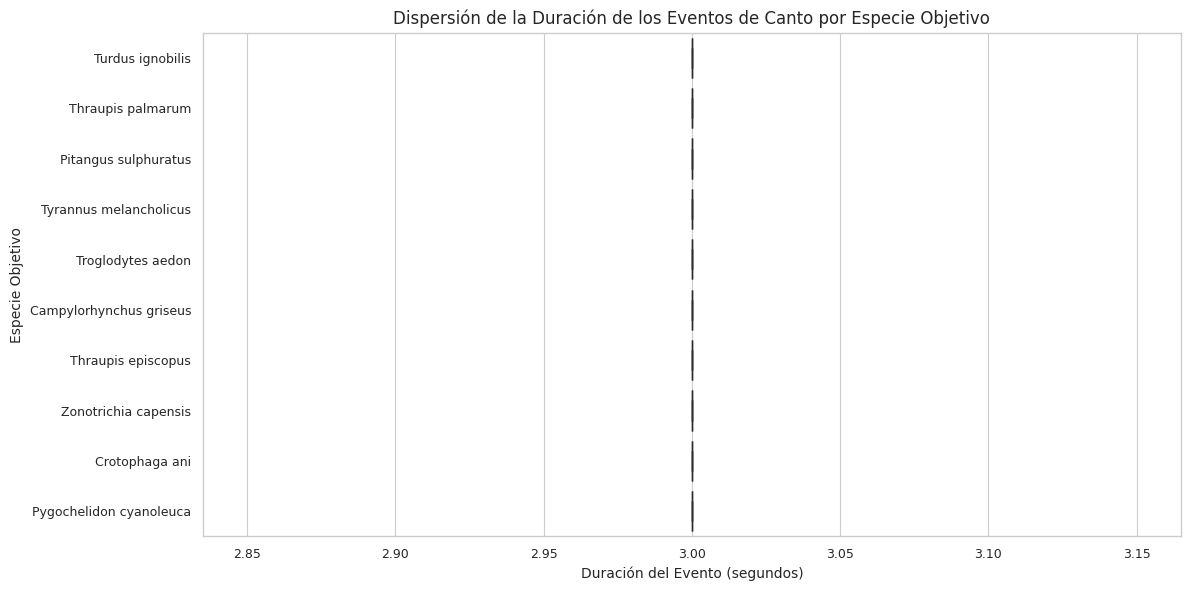

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/distribucion_duracion_eventos_especie.png


In [6]:
# 1. Calcular en una nueva columna la duración individual de cada segmento en segundos
df_labels["duracion_evento"] = df_labels["fin_segundo"] - df_labels["inicio_segundo"]

# 2. Calcular estadísticas descriptivas agrupadas por especie target
stats_duracion_eventos = df_labels.groupby("especie_target")["duracion_evento"].agg(
    Cantidad_Eventos="count",
    Media_s="mean",
    Mediana_s="median",
    Desviacion_s="std",
    Minimo_s="min",
    Maximo_s="max"
).round(2)

print("=== ESTADÍSTICAS DE DURACIÓN DE EVENTOS DE CANTO POR ESPECIE ===")
display(stats_duracion_eventos)

# 3. Generar gráfico de caja comparativo (Boxplot) para evaluar la dispersión
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_labels,
    x="duracion_evento",
    y="especie_target",
    palette="viridis",
    hue="especie_target",
    legend=False,
    showfliers=False  # Omitimos valores atípicos (outliers) extremos para facilitar la lectura del gráfico
)

plt.title("Dispersión de la Duración de los Eventos de Canto por Especie Objetivo")
plt.xlabel("Duración del Evento (segundos)")
plt.ylabel("Especie Objetivo")
plt.tight_layout()

# 4. Guardar físicamente la figura en disco para informes o presentación
fig_path_dur_eventos = "../artifacts/figures/eda/distribucion_duracion_eventos_especie.png"
plt.savefig(fig_path_dur_eventos, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path_dur_eventos)}")

### 4.6. Análisis de Distribución Temporal de Eventos (Puntos de Inicio / Onsets)

En la detección de eventos sonoros (SED), es de vital importancia diagnosticar si existe un sesgo sistemático en la localización temporal de las vocalizaciones dentro de los audios. Por ejemplo, si todos los cantos se concentraran exclusivamente en los primeros segundos de cada archivo, entrenar el modelo dividiendo las grabaciones en ventanas fijas de 10 segundos [5] podría provocar que el modelo aprenda sesgos artificiales de posición y falle al generalizar en audios extensos en vivo.

Analizaremos estadísticamente los **tiempos de inicio (`inicio_segundo`)** de los 5641 segmentos de canto unificados en el corpus [5]. Esto nos permitirá diagnosticar si los cantos se distribuyen de manera homogénea a lo largo de las escalas de tiempo de los archivos de audio de Xeno-Canto o si presentan concentraciones locales, comparando este comportamiento de dispersión entre las 10 especies objetivo.

=== ESTADÍSTICAS DE TIEMPO DE INICIO (ONSET) DE EVENTOS ===
Punto de inicio promedio (media): 172.19 segundos
Punto de inicio mediano:          24.00 segundos
Desviación estándar:             507.99 segundos
Inicio más temprano registrado:   0.00 segundos
Inicio más tardío registrado:     2736.00 segundos



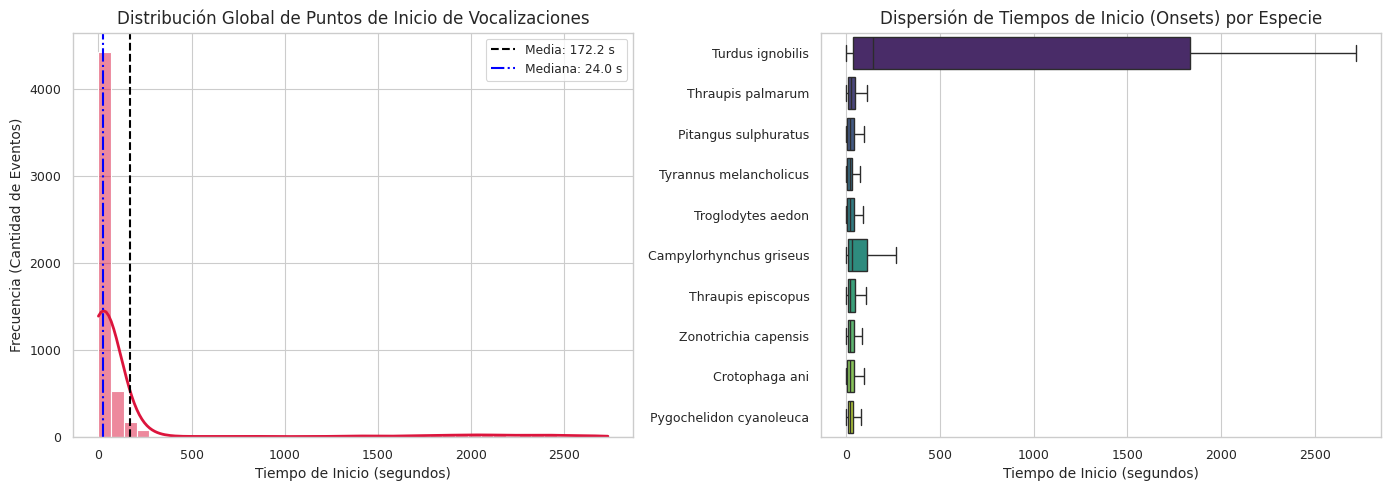

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/distribucion_temporal_inicio_eventos.png


In [7]:
# 1. Calcular estadísticas descriptivas básicas del punto de inicio (onset) de las vocalizaciones
onsets = df_labels["inicio_segundo"]

print("=== ESTADÍSTICAS DE TIEMPO DE INICIO (ONSET) DE EVENTOS ===")
print(f"Punto de inicio promedio (media): {onsets.mean():.2f} segundos")
print(f"Punto de inicio mediano:          {onsets.median():.2f} segundos")
print(f"Desviación estándar:             {onsets.std():.2f} segundos")
print(f"Inicio más temprano registrado:   {onsets.min():.2f} segundos")
print(f"Inicio más tardío registrado:     {onsets.max():.2f} segundos\n")

# 2. Generar lienzo gráfico de subplots compartidos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Histograma global y densidad (KDE) de los onsets
sns.histplot(
    onsets,
    kde=True,
    color="crimson",
    bins=40,
    ax=axes[0],
    line_kws={"linewidth": 2}
)
axes[0].axvline(onsets.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Media: {onsets.mean():.1f} s")
axes[0].axvline(onsets.median(), color="blue", linestyle="-.", linewidth=1.5, label=f"Mediana: {onsets.median():.1f} s")
axes[0].set_title("Distribución Global de Puntos de Inicio de Vocalizaciones")
axes[0].set_xlabel("Tiempo de Inicio (segundos)")
axes[0].set_ylabel("Frecuencia (Cantidad de Eventos)")
axes[0].legend()

# Subplot 2: Comparación de la dispersión de onsets por especie objetivo usando un Boxplot
sns.boxplot(
    data=df_labels,
    x="inicio_segundo",
    y="especie_target",
    palette="viridis",
    hue="especie_target",
    legend=False,
    ax=axes[1],
    showfliers=False  # Omitimos outliers de colas muy largas para enfocar el rango dinámico del percentil 25 al 75
)
axes[1].set_title("Dispersión de Tiempos de Inicio (Onsets) por Especie")
axes[1].set_xlabel("Tiempo de Inicio (segundos)")
axes[1].set_ylabel("")  # Omitimos etiqueta redundante para evitar saturar el gráfico

plt.tight_layout()

# 3. Guardar físicamente la figura en disco para informes o presentación
fig_path_temporal = "../artifacts/figures/eda/distribucion_temporal_inicio_eventos.png"
plt.savefig(fig_path_temporal, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path_temporal)}")

### 4.7. Análisis de la Confianza de las Pseudo-Etiquetas de BirdNET

Los segmentos de canto unificados en nuestro dataset poseen una métrica de **confianza estadística** calculada directamente por BirdNET (valor normalizado entre $0.00$ y $1.00$) [5]. Dado que fijamos de forma intencional un umbral permisivo de `min_conf=0.10` en la Fase 1 para capturar trinos lejanos y no sesgar los límites temporales del canto, resulta imperativo auditar la calidad e idoneidad de esta señal de supervisión débil [5].

Si la masa de nuestras pseudo-etiquetas se concentrara mayoritariamente en vecindades adyacentes a $0.10$, significaría que los datos de entrenamiento contienen altos niveles de ruido e incertidumbre. Por el contrario, distribuciones concentradas en rangos mayores (como por encima de $0.50$ o $0.70$) representarán una señal de supervisión mucho más nítida para la red neuronal. Analizaremos esta distribución a continuación de forma global y por especie objetivo [5].

=== ESTADÍSTICAS DE CONFIANZA DE BIRDNET ===
Confianza promedio (media): 0.6139
Confianza mediana:          0.6592
Desviación estándar:        0.3151
Confianza mínima:           0.1000
Confianza máxima:           1.0000



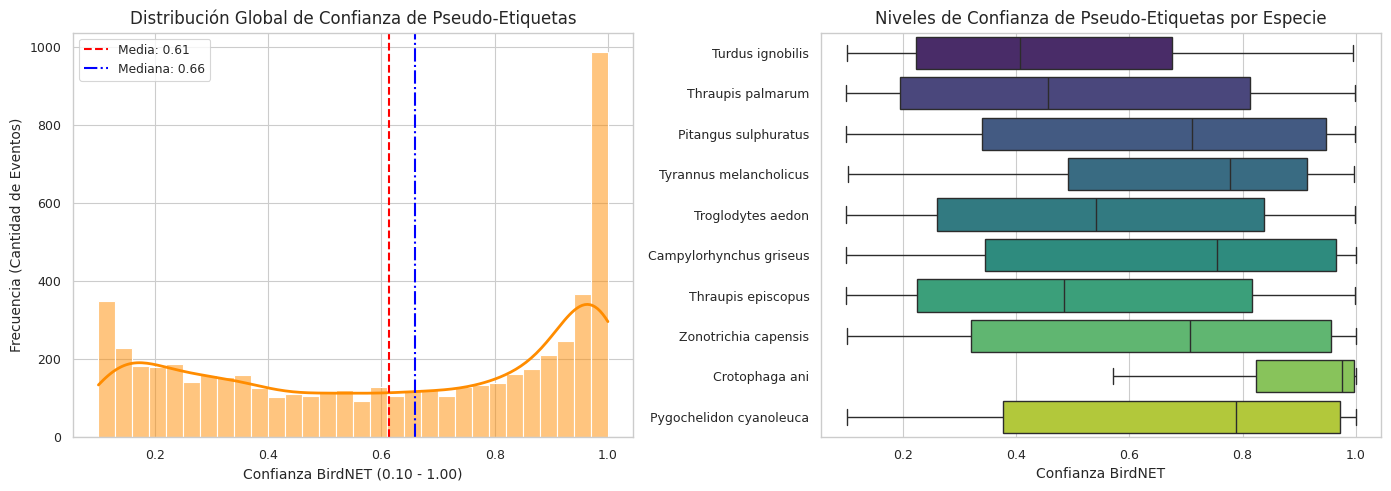

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/distribucion_confianza_birdnet.png


In [8]:
# 1. Calcular estadísticas descriptivas de la confianza de las detecciones registradas
confianzas = df_labels["confianza_birdnet"]

print("=== ESTADÍSTICAS DE CONFIANZA DE BIRDNET ===")
print(f"Confianza promedio (media): {confianzas.mean():.4f}")
print(f"Confianza mediana:          {confianzas.median():.4f}")
print(f"Desviación estándar:        {confianzas.std():.4f}")
print(f"Confianza mínima:           {confianzas.min():.4f}")
print(f"Confianza máxima:           {confianzas.max():.4f}\n")

# 2. Generar lienzo gráfico de subplots compartidos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Histograma global y curva de densidad (KDE) de la confianza
sns.histplot(
    confianzas,
    kde=True,
    color="darkorange",
    bins=30,
    ax=axes[0],
    line_kws={"linewidth": 2}
)
axes[0].axvline(confianzas.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Media: {confianzas.mean():.2f}")
axes[0].axvline(confianzas.median(), color="blue", linestyle="-.", linewidth=1.5, label=f"Mediana: {confianzas.median():.2f}")
axes[0].set_title("Distribución Global de Confianza de Pseudo-Etiquetas")
axes[0].set_xlabel("Confianza BirdNET (0.10 - 1.00)")
axes[0].set_ylabel("Frecuencia (Cantidad de Eventos)")
axes[0].legend()

# Subplot 2: Comparación de la confianza por especie objetivo usando un Boxplot
sns.boxplot(
    data=df_labels,
    x="confianza_birdnet",
    y="especie_target",
    palette="viridis",
    hue="especie_target",
    legend=False,
    ax=axes[1],
    showfliers=False  # Omitimos outliers de colas largas para concentrarnos en los percentiles del dataset principal
)
axes[1].set_title("Niveles de Confianza de Pseudo-Etiquetas por Especie")
axes[1].set_xlabel("Confianza BirdNET")
axes[1].set_ylabel("")  # Omitimos etiqueta redundante para evitar saturar el gráfico

plt.tight_layout()

# 3. Guardar físicamente la figura en disco para informes o presentación
fig_path_confianza = "../artifacts/figures/eda/distribucion_confianza_birdnet.png"
plt.savefig(fig_path_confianza, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path_confianza)}")

### 4.8. Identificación Analítica de Audios Anómalos y Atípicos (*Outliers*)

Para finalizar la auditoría de los datos tabulares del corpus, realizaremos una **detección sistemática de audios anómalos o atípicos**. Aunque estos archivos superaron con éxito la prueba física de decodificación en el Paso 1.6, sus parámetros estadísticos extremos pueden sesgar, dificultar o limitar la convergencia del entrenamiento de la CRNN [5].

Identificaremos programáticamente cuatro categorías de anomalías en el dataset:
1.  **Audios Excesivamente Cortos (< 10 segundos)**: Dado que el cargador de datos recorta y procesa ventanas fijas de 10 segundos, archivos muy cortos se rellenarán en su mayoría con silencio artificial (*zero-padding*), reduciendo la densidad informativa.
2.  **Audios Muy Extensos (> 150 segundos)**: Archivos de larga duración que se alejan significativamente de la mediana del corpus y ralentizan el procesamiento si no son controlados.
3.  **Audios con Baja Fidelidad Original (< 22.05 kHz)**: Grabaciones capturadas originalmente a tasas de muestreo muy bajas (como 8 kHz u 11 kHz). Aunque las remuestreamos a 32 kHz, sufrieron una pérdida física e irreversible de información de altas frecuencias (su límite de Nyquist original era inferior a 11 kHz).
4.  **Audios "Mudos" para las 10 Especies**: Grabaciones donde BirdNET no identificó de manera robusta ninguna de las 10 especies objetivo de Medellín en ningún segundo [5]. Estos archivos son normales y actuarán como ejemplos negativos (silencio de fondo o ruido ambiental) en el entrenamiento de la CRNN. Es vital conocer su volumen.

In [9]:
# 1. Definir los umbrales estadísticos de anomalía y outliers
UMBRAL_CORTO = 10.0      # segundos
UMBRAL_LARGO = 150.0     # segundos
UMBRAL_BAJO_SR = 22050   # Hz

# 2. Identificar audios excesivamente cortos
audios_cortos = df_metadata[df_metadata["duracion_real"] < UMBRAL_CORTO]

# 3. Identificar audios excesivamente largos
audios_largos = df_metadata[df_metadata["duracion_real"] > UMBRAL_LARGO]

# 4. Identificar audios grabados originalmente con baja fidelidad (baja tasa de muestreo)
audios_baja_fidelidad = df_metadata[df_metadata["sample_rate_real"] < UMBRAL_BAJO_SR]

# 5. Identificar audios "mudos" (sin ninguna detección de BirdNET para las 10 especies)
# Extraer IDs de audios que sí tienen al menos una etiqueta fuerte en df_labels
ids_con_etiquetas = df_labels["archivo_original"].str.replace(".mp3", "", regex=False).astype(int).unique()
audios_mudos = df_metadata[~df_metadata["id_audio"].isin(ids_con_etiquetas)]

print("=== REPORTE ANALÍTICO DE ANOMALÍAS Y OUTLIERS ===")
print(f"Total de audios válidos analizados: {len(df_metadata)}")

print(f"\n1. Audios demasiado cortos (< {UMBRAL_CORTO} s): {len(audios_cortos)} archivos ({len(audios_cortos)/len(df_metadata)*100:.2f}%)")
if not audios_cortos.empty:
    display(audios_cortos[["id_audio", "especie_esperada", "duracion_real"]].head(3))

print(f"\n2. Audios muy extensos (> {UMBRAL_LARGO} s): {len(audios_largos)} archivos ({len(audios_largos)/len(df_metadata)*100:.2f}%)")
if not audios_largos.empty:
    display(audios_largos[["id_audio", "especie_esperada", "duracion_real"]].head(3))

print(f"\n3. Audios grabados con baja fidelidad original (< {UMBRAL_BAJO_SR} Hz): {len(audios_baja_fidelidad)} archivos ({len(audios_baja_fidelidad)/len(df_metadata)*100:.2f}%)")
if not audios_baja_fidelidad.empty:
    display(audios_baja_fidelidad[["id_audio", "especie_esperada", "sample_rate_real"]].head(3))

print(f"\n4. Audios 'mudos' (sin detecciones de las 10 especies): {len(audios_mudos)} archivos ({len(audios_mudos)/len(df_metadata)*100:.2f}%)")
print("   *Nota: Estos audios actuarán como valiosos ejemplos negativos (silencio/ruido) para evitar falsos positivos de la CRNN.")
if not audios_mudos.empty:
    display(audios_mudos[["id_audio", "especie_esperada"]].head(3))

=== REPORTE ANALÍTICO DE ANOMALÍAS Y OUTLIERS ===
Total de audios válidos analizados: 751

1. Audios demasiado cortos (< 10.0 s): 120 archivos (15.98%)


,id_audio,especie_esperada,duracion_real
1,742377,Turdus ignobilis,4.556500
5,528032,Turdus ignobilis,2.900771
36,157668,Turdus ignobilis,7.445034



2. Audios muy extensos (> 150.0 s): 17 archivos (2.26%)


,id_audio,especie_esperada,duracion_real
26,432829,Turdus ignobilis,266.510187
38,147860,Turdus ignobilis,2739.696327
89,315202,Pitangus sulphuratus,158.976979



3. Audios grabados con baja fidelidad original (< 22050 Hz): 5 archivos (0.67%)


,id_audio,especie_esperada,sample_rate_real
109,747002,Pitangus sulphuratus,16000.0
189,743171,Thraupis episcopus,16000.0
581,747131,Crotophaga ani,16000.0



4. Audios 'mudos' (sin detecciones de las 10 especies): 102 archivos (13.58%)
   *Nota: Estos audios actuarán como valiosos ejemplos negativos (silencio/ruido) para evitar falsos positivos de la CRNN.


,id_audio,especie_esperada
2,683965,Turdus ignobilis
5,528032,Turdus ignobilis
10,125997,Turdus ignobilis


## 5. Representación Acústica Visual: Waveform, STFT y Log-Mel

### 5.1. Comparación de Representaciones Acústicas

Para comprender de forma intuitiva cómo las transformaciones matemáticas aplicadas alteran la representación de la señal física original, analizaremos visualmente un clip de audio de prueba de nuestro corpus (por ejemplo, *Turdus ignobilis*).

Generaremos un lienzo de tres paneles apilados temporalmente para comparar directamente de arriba a abajo:
1.  **La Onda Temporal Cruda (Waveform)**: Representa la amplitud de presión acústica normalizada $\hat{x}[n]$ en función del tiempo. Permite identificar la envolvente de volumen de los cantos frente al silencio, pero oculta completamente la firma de sus componentes de frecuencia.
2.  **El Espectrograma de Frecuencia Lineal (STFT)**: Muestra la densidad espectral de amplitud en decibelios a lo largo de un eje de frecuencias medido linealmente en Hertz ($\text{Hz}$) [5]. Permite observar con gran definición la frecuencia fundamental y la estructura armónica física de los silbidos, pero conserva una alta redundancia en el espectro de alta frecuencia [5].
3.  **El Espectrograma Log-Mel**: Es la matriz de características final $M(m, j)$ [5]. Su eje de frecuencia vertical está escalado no linealmente en bines psicoacústicos Mel (64 bines) y su escala de colores comprime de forma logarítmica la potencia en decibelios [5]. Esta es exactamente la "imagen" bidimensional de entrada que alimentará a los filtros convolucionales 2D de nuestro modelo durante el entrenamiento [5].

Cargando grabación de ejemplo para análisis visual:
  - Especie:  Turdus ignobilis
  - ID Audio: 742378
  - Ruta:     ../dataset_aves/Turdus_ignobilis/742378.mp3


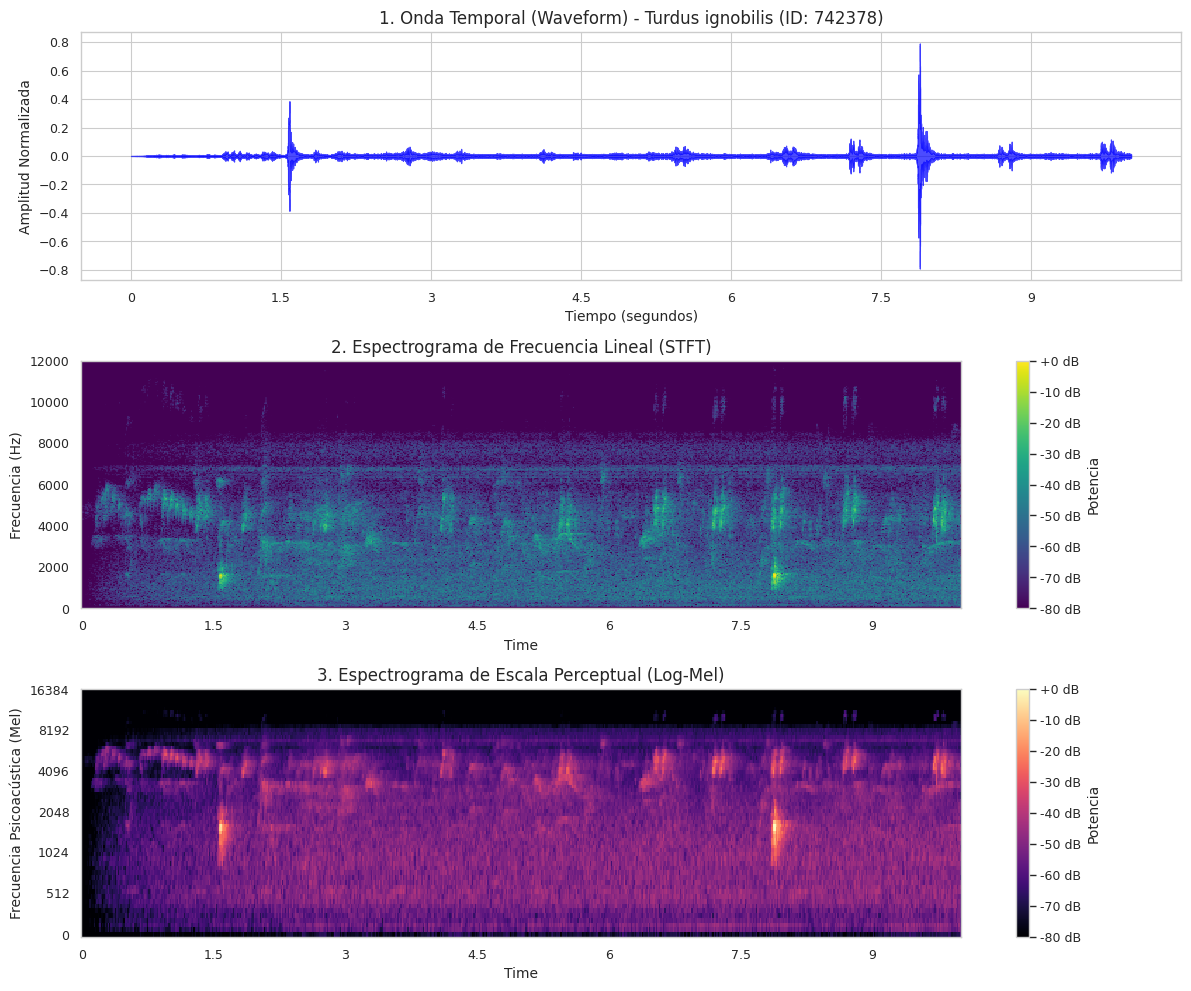

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/comparacion_visual_representaciones.png


In [10]:
# 1. Seleccionar de forma dinámica el primer audio válido de metadatos (un Turdus ignobilis)
ejemplo_row = df_metadata.iloc[0]
id_audio_test = ejemplo_row["id_audio"]
especie_test = ejemplo_row["especie_esperada"]
nombre_carpeta_test = especie_test.replace(" ", "_")
ruta_audio_test = os.path.join(BASE_DIR, nombre_carpeta_test, f"{id_audio_test}.mp3")

print(f"Cargando grabación de ejemplo para análisis visual:")
print(f"  - Especie:  {especie_test}")
print(f"  - ID Audio: {id_audio_test}")
print(f"  - Ruta:     {ruta_audio_test}")

# 2. Cargar y preprocesar el audio (idéntico al pipeline de entrenamiento de la CRNN)
# Cargamos a 32 kHz de forma monoaural
y, sr = librosa.load(ruta_audio_test, sr=32000, mono=True)

# Truncar o rellenar (padding) a exactamente 10 segundos para consistencia temporal
duracion_objetivo = 10  # segundos
muestras_objetivo = duracion_objetivo * sr
if len(y) > muestras_objetivo:
    y = y[:muestras_objetivo]
else:
    y = np.pad(y, (0, muestras_objetivo - len(y)), mode='constant')

# 3. Calcular las representaciones espectrales físicas y psicoacústicas
n_fft = 1024
hop_length = 512
n_mels = 64

# A. Transformada de Fourier de Tiempo Corto (STFT)
stft_compleja = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
stft_amplitud_db = librosa.amplitude_to_db(np.abs(stft_compleja), ref=np.max)

# B. Espectrograma Log-Mel (banco de filtros de Mel)
mel_spectrogram = librosa.feature.melspectrogram(
    y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
)
log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

# 4. Diseñar lienzo de graficación vertical de 3 paneles apilados
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Panel 1: Waveform (Onda de presión en función del tiempo)
librosa.display.waveshow(y, sr=sr, ax=axes[0], color="blue", alpha=0.7)
axes[0].set_title(f"1. Onda Temporal (Waveform) - {especie_test} (ID: {id_audio_test})")
axes[0].set_ylabel("Amplitud Normalizada")
axes[0].set_xlabel("Tiempo (segundos)")

# Panel 2: Espectrograma de Frecuencia Lineal (STFT)
img1 = librosa.display.specshow(
    stft_amplitud_db, 
    sr=sr, 
    hop_length=hop_length, 
    x_axis="time", 
    y_axis="linear", 
    ax=axes[1], 
    cmap="viridis"
)
axes[1].set_title("2. Espectrograma de Frecuencia Lineal (STFT)")
axes[1].set_ylabel("Frecuencia (Hz)")
axes[1].set_ylim(0, 12000)  # Acotamos el eje vertical a los 12 kHz para apreciar las frecuencias audibles
fig.colorbar(img1, ax=axes[1], format="%+2.0f dB", label="Potencia")

# Panel 3: Espectrograma Log-Mel
img2 = librosa.display.specshow(
    log_mel_spectrogram, 
    sr=sr, 
    hop_length=hop_length, 
    x_axis="time", 
    y_axis="mel", 
    ax=axes[2], 
    cmap="magma"
)
axes[2].set_title("3. Espectrograma de Escala Perceptual (Log-Mel)")
axes[2].set_ylabel("Frecuencia Psicoacústica (Mel)")
fig.colorbar(img2, ax=axes[2], format="%+2.0f dB", label="Potencia")

plt.tight_layout()

# 5. Guardar físicamente la figura en disco para informes o presentación
fig_path_rep = "../artifacts/figures/eda/comparacion_visual_representaciones.png"
plt.savefig(fig_path_rep, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path_rep)}")

### 5.2. Comparación de Firmas Espectrales: Patrones Armónicos vs. Banda Ancha Difusa

Desde el enfoque del modelado convolucional (CNN), la dificultad de clasificación de una especie acústica está estrechamente ligada a la geometría y nitidez de su firma en el espectrogramas Log-Mel [5]. Algunas aves emiten trinos puros de alto contraste y estructura periódica, mientras que otras emiten llamados difusos que comparten características espectrales con el ruido del viento, la lluvia o el follaje de Medellín.

Realizaremos una comparación lado a lado para contrastar estas dos naturalezas físicas:
1.  **Firma Espectral Definida/Armónica (*Pitangus sulphuratus* - Bichofué)**: El Bichofué emite silbidos potentes y limpios. En el espectrograma, esto se traduce en líneas horizontales nítidas y paralelas de alta potencia (armónicos fundamentales definidos) con silencios claros entre cantos. Esta estructura geométrica de alto contraste es idónea para ser extraída por los filtros convolucionales 2D.
2.  **Firma Espectral Difusa/Banda Ancha (*Pygochelidon cyanoleuca* - Golondrina Barranquera)**: Las golondrinas emiten vocalizaciones tipo zumbido (*buzz*). En el espectrograma, estos sonidos se manifiestan como bloques gruesos y difusos de energía que abarcan un amplio espectro vertical de frecuencias (banda ancha). Debido a que no tienen armónicos puros y se asemejan al ruido térmico o ambiental, plantean una frontera de decisión mucho más compleja para la red neuronal convolucional.

Calculando espectrogramas comparativos para firmas acústicas...


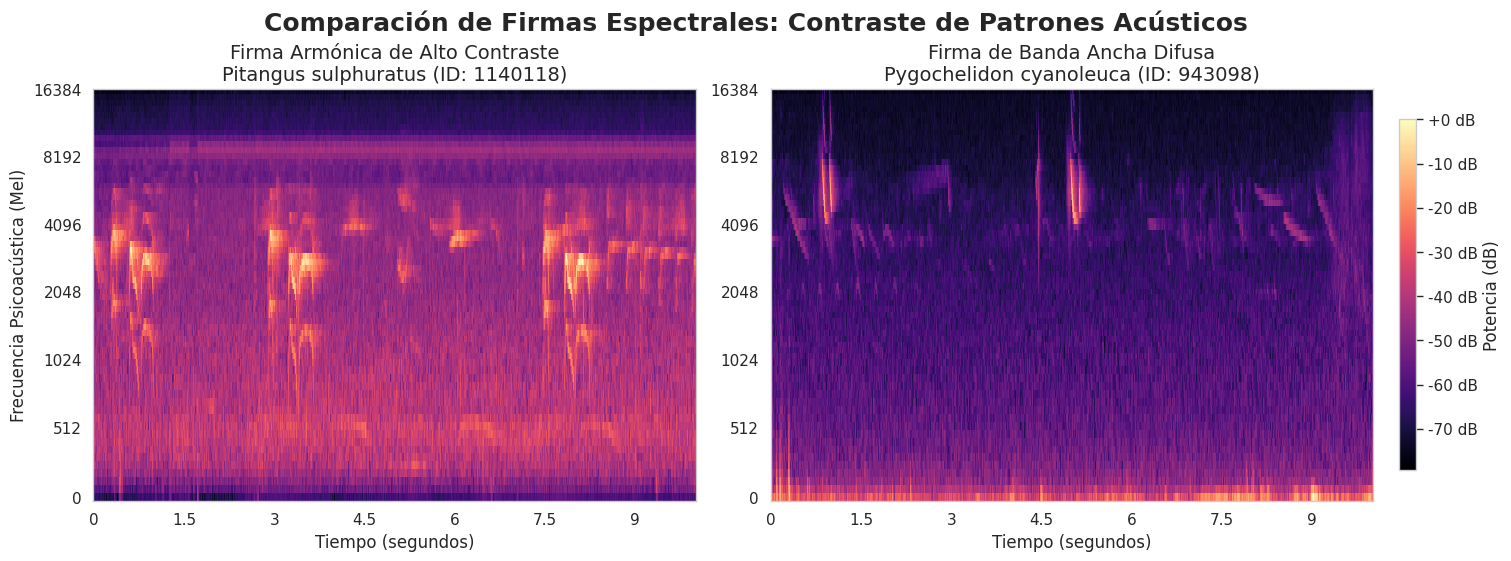

Figura guardada con éxito en: /home/els4nchez/Pictures/Bird-Recognition-using-BioSED-model/artifacts/figures/eda/comparacion_firmas_espectrales.png


In [21]:
# 1. Localizar dinámicamente un audio de Pitangus sulphuratus (Bichofué)
bichofue_row = df_metadata[df_metadata["especie_esperada"] == "Pitangus sulphuratus"].iloc[0]
ruta_bichofue = os.path.join(BASE_DIR, "Pitangus_sulphuratus", f"{bichofue_row['id_audio']}.mp3")

# 2. Localizar dinámicamente un audio de Pygochelidon cyanoleuca (Golondrina)
golondrina_row = df_metadata[df_metadata["especie_esperada"] == "Pygochelidon cyanoleuca"].iloc[0]
ruta_golondrina = os.path.join(BASE_DIR, "Pygochelidon_cyanoleuca", f"{golondrina_row['id_audio']}.mp3")

# 3. Función auxiliar local para procesar el Log-Mel de visualización a 10s
def obtener_log_mel_10s(ruta_audio):
    y_proc, sr_proc = librosa.load(ruta_audio, sr=32000, mono=True)
    muestras_lim = 10 * sr_proc
    if len(y_proc) > muestras_lim:
        y_proc = y_proc[:muestras_lim]
    else:
        y_proc = np.pad(y_proc, (0, muestras_lim - len(y_proc)), mode='constant')
    
    mel_spec_proc = librosa.feature.melspectrogram(
        y=y_proc, sr=sr_proc, n_fft=1024, hop_length=512, n_mels=64
    )
    return librosa.power_to_db(mel_spec_proc, ref=np.max)

print("Calculando espectrogramas comparativos para firmas acústicas...")
mel_bichofue = obtener_log_mel_10s(ruta_bichofue)
mel_golondrina = obtener_log_mel_10s(ruta_golondrina)

# 4. Graficar ambas firmas espectrales lado a lado utilizando constrained_layout
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

# Título general de la figura (tipografía de gran tamaño: 18)
fig.suptitle(
    "Comparación de Firmas Espectrales: Contraste de Patrones Acústicos", 
    fontsize=18, 
    fontweight="bold"
)

# Panel Izquierdo: Pitangus sulphuratus (Firma armónica limpia)
img_left = librosa.display.specshow(
    mel_bichofue, 
    sr=32000, 
    hop_length=512, 
    x_axis="time", 
    y_axis="mel", 
    ax=axes[0], 
    cmap="magma"
)
# Aumento de títulos a 14 y etiquetas de ejes a 12
axes[0].set_title(
    f"Firma Armónica de Alto Contraste\n"
    f"Pitangus sulphuratus (ID: {bichofue_row['id_audio']})", 
    fontsize=14
)
axes[0].set_ylabel("Frecuencia Psicoacústica (Mel)", fontsize=12)
axes[0].set_xlabel("Tiempo (segundos)", fontsize=12)

# Aumentar tamaño de los números en los ejes (ticks a 11)
axes[0].tick_params(axis='both', which='major', labelsize=11)

# Panel Derecho: Pygochelidon cyanoleuca (Firma ruidosa/banda ancha)
img_right = librosa.display.specshow(
    mel_golondrina, 
    sr=32000, 
    hop_length=512, 
    x_axis="time", 
    y_axis="mel", 
    ax=axes[1], 
    cmap="magma"
)
# Aumento de títulos a 14 y etiquetas de ejes a 12
axes[1].set_title(
    f"Firma de Banda Ancha Difusa\n"
    f"Pygochelidon cyanoleuca (ID: {golondrina_row['id_audio']})", 
    fontsize=14
)
axes[1].set_ylabel("")  # Omitimos la etiqueta del eje Y para mantener la simetría
axes[1].set_xlabel("Tiempo (segundos)", fontsize=12)

# Aumentar tamaño de los números en los ejes (ticks a 11)
axes[1].tick_params(axis='both', which='major', labelsize=11)

# 5. Añadir barra de color externa compartida y configurar sus fuentes
cbar = fig.colorbar(
    img_right, 
    ax=axes, 
    format="%+2.0f dB", 
    shrink=0.85, 
    pad=0.02
)
# Configurar fuentes de la barra de color (etiqueta a 12 y números a 11)
cbar.set_label("Potencia (dB)", fontsize=12)
cbar.ax.tick_params(labelsize=11)

# Guardar físicamente la figura en disco para informes o presentación
fig_path_comp = "../artifacts/figures/eda/comparacion_firmas_espectrales.png"
plt.savefig(fig_path_comp, dpi=300)
plt.show()

print(f"Figura guardada con éxito en: {os.path.abspath(fig_path_comp)}")

## 6. Discusión de Riesgos Estadísticos, Sesgos y Limitaciones del Dataset

A partir de las métricas estadísticas y las visualizaciones espectrales consolidadas en este notebook, es posible identificar cuatro riesgos metodológicos críticos que deben ser considerados para el diseño, entrenamiento y evaluación del modelo predictivo CRNN [5].

### 6.1. Desbalance de Clases Intrínseco a Nivel de Frame
Aunque el dataset a nivel de archivos físicos de audio (*clip-level*) se encuentra razonablemente balanceado tras recopilar la base de datos completa de Colombia (con la mayoría de las especies rondando entre 60 y 100 archivos), el análisis descriptivo de las etiquetas fuertes revela un desbalance masivo a nivel de segmentos activos de canto [5]:
*   Especies altamente vocales y gregarias como *Pitangus sulphuratus* o *Pygochelidon cyanoleuca* presentan una densidad acústica sumamente alta (más de 10 eventos de canto promedio por cada clip de 10 segundos) [5].
*   Especies más discretas en sus hábitos acústicos como *Troglodytes aedon* o *Crotophaga ani* registran densidades bajas (menos de 4 eventos por clip) [5].

**Implicación para el Modelo**: Dado que el modelo predice probabilidades frame-a-frame de forma multi-etiqueta, el conjunto de entrenamiento final tendrá una cantidad desproporcionadamente mayor de muestras positivas ("unos") para las especies densas frente a las dispersas. Esto puede provocar que la red aprenda a predecir con mayor facilidad a las clases dominantes. Durante la evaluación (Notebook 04), será vital utilizar el **Average Precision (AP) por clase** y no el Accuracy global para medir el desempeño real de forma justa.

### 6.2. Ruido Ambiental Urbano del Valle de Aburrá
Las grabaciones acústicas obtenidas de ciencia ciudadana fueron registradas en condiciones de campo reales, muchas de ellas en entornos urbanos y semiurbanos de Medellín. El Log-Mel Spectrogram de entrada $M(m, j)$ no solo captura las frecuencias puras de las aves, sino también el ruido de fondo característico de estos ecosistemas:
*   **Ruido antropogénico**: Tráfico vehicular, motores, bocinas e infraestructura urbana, caracterizados por concentraciones de alta energía en el espectro de muy baja frecuencia (< 1000 Hz).
*   **Ruido meteorológico**: Lluvia y viento, que se manifiestan como bandas anchas de energía difusa y bajo contraste (similar a la firma de la golondrina *Pygochelidon cyanoleuca*).

**Implicación para el Modelo**: El modelo convolucional (CNN) corre el riesgo de asociar patrones de ruido de fondo recurrentes (por ejemplo, el zumbido de un motor de baja frecuencia) con especies específicas si estas fueron grabadas con frecuencia en parches urbanos densos. Esto constituiría un sesgo de correlación espuria.

### 6.3. Sesgo Sistemático por Pseudo-Etiquetado (Weak Supervision)
Es mandatorio recordar que las etiquetas de inicio y fin de canto provienen de un detector automatizado (*BirdNET*) y no de una inspección humana experta [5]. Esto implica que nuestro pipeline de aprendizaje es un esquema de **destilación de conocimiento (Knowledge Distillation)** débilmente supervisado:
*   El modelo final no aprenderá directamente la "verdad biológica" absoluta de los cantos, sino que aprenderá a imitar la frontera de decisión y los sesgos del clasificador de Cornell [5].
*   Si BirdNET presenta un error sistemático (por ejemplo, confundir trinos rápidos de *Thraupis palmarum* con *Thraupis episcopus* debido a su cercanía taxonómica), nuestro modelo heredará y reproducirá ese mismo error de clasificación.

### 6.4. Riesgo de Fuga de Información (Data Leakage)
En la Fase 3 realizaremos la partición del dataset en subconjuntos de Entrenamiento, Validación y Prueba [5]. Si realizáramos un split aleatorio simple a nivel de segmentos de canto individuales, cometeríamos una **fuga de información crítica**:
*   Varios segmentos de canto pertenecen físicamente al mismo archivo de audio. Si un fragmento de un archivo $A$ va a entrenamiento y otro fragmento del mismo archivo $A$ va a prueba, el modelo de validación se evaluará sobre condiciones acústicas idénticas (mismo grabador, mismo micrófono de origen, idéntico ruido de fondo y el mismo espécimen individual de ave).
*   Esto inflaría de forma artificial e irreal las métricas de desempeño de validación, ocultando un sobreajuste severo.

**Estrategia de Mitigación**: El split de datos en el Notebook 03 debe realizarse estrictamente **a nivel de archivo de audio (clip-level)**, asegurando que todos los segmentos temporales de un audio específico pertenezcan exclusivamente a un único subconjunto (Train, Val o Test), garantizando la honestidad científica de la evaluación [5].

## 7. Cierre de Fase e Inventario de Recursos para la Presentación

Para finalizar la ejecución del Notebook 02, realizaremos una **auditoría y exportación automatizada de las figuras generadas**. Este paso de control de calidad verifica la existencia física de los gráficos estadísticos y mapas espectrales de calor guardados en el disco duro durante este notebook, indicando sus rutas de almacenamiento absolutas y sus pesos en disco.

De esta forma, podrás ubicar y copiar directamente estos recursos gráficos de alta resolución (300 DPI) para incorporarlos de forma limpia en tu informe final o en las diapositivas de la sustentación de la materia Física Computacional 2: Aprendizaje Estadístico.

In [22]:
# Definir la ruta del directorio físico donde se guardaron las figuras
fig_dir_eda = "../artifacts/figures/eda"

print("=== INICIANDO INVENTARIO DE FIGURAS EXPORTADAS PARA PRESENTACIÓN ===")

if os.path.exists(fig_dir_eda):
    # Buscar todos los archivos de imagen de extensión .png generados
    archivos_figuras = [f for f in os.listdir(fig_dir_eda) if f.endswith(".png")]
    
    if archivos_figuras:
        print(f"Éxito: Se localizaron {len(archivos_figuras)} figuras de alta resolución en disco:\n")
        
        # Armar una lista estructurada para visualización tabular de los metadatos de las imágenes
        reporte_figuras = []
        for fig_file in sorted(archivos_figuras):
            ruta_completa_fig = os.path.join(fig_dir_eda, fig_file)
            peso_kb = os.path.getsize(ruta_completa_fig) / 1024
            reporte_figuras.append({
                "Nombre del Archivo": fig_file,
                "Tamaño (KB)": f"{peso_kb:.2f} KB",
                "Ruta Absoluta": os.path.abspath(ruta_completa_fig)
            })
        
        df_reporte_figs = pd.DataFrame(reporte_figuras)
        display(df_reporte_figs)
    else:
        print("[ERROR] No se encontraron archivos .png en el directorio de figuras de EDA.")
else:
    print("[ERROR] No existe el directorio físico de figuras configurado.")

=== INICIANDO INVENTARIO DE FIGURAS EXPORTADAS PARA PRESENTACIÓN ===
Éxito: Se localizaron 9 figuras de alta resolución en disco:



,Nombre del Archivo,Tamaño (KB),Ruta Absoluta
0,balance_clips_especies.png,227.39 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
1,cantidad_eventos_especie.png,241.29 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
2,comparacion_firmas_espectrales.png,502.57 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
3,comparacion_visual_representaciones.png,1079.08 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
4,distribucion_confianza_birdnet.png,250.77 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
5,distribucion_duracion_audios.png,134.32 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
6,distribucion_duracion_eventos_especie.png,181.58 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
7,distribucion_temporal_inicio_eventos.png,246.14 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
8,parametros_tecnicos_audios.png,175.14 KB,/home/els4nchez/Pictures/Bird-Recognition-usin...
